# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [1]:
!python -m pip install kaggle==1.6.12

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install --target=/workspace ucimlrepo numpy==1.24.3

  Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
  Using cached numpy-1.24.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
  Using cached certifi-2025.11.12-py3-none-any.whl (159 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)


**Note:** Restart the kernel to use updated package(s).

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

Problem Statement: How do the genres and release years of movies in general compare to those available on Netflix?

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1: The Movies Dataset**

Type: CSV Files

This dataset offers detailed metadata about a wide range of movies, including release dates, genres, budgets, revenues, and other key attributes. It is valuable for understanding the general trends in movie production and popularity across the industry. It is also one of the biggest movie datasets available to us, allowing suitable comparisons with Netflix Dataset

Method: The dataset was downloaded programmatically using the kagglehub Python package, which provides an interface to access Kaggle datasets directly from a Python environment.

Dataset variables:

adult: indicates whether the movie is adult/18+ rated

belongs_to_collection: information about the collection/franchise the movie is part of

budget: production budget of the movie

genres: list of genre categories assigned to the movie

homepage: official website URL of the movie

id: unique movie identifier used by TMDB

imdb_id: unique movie identifier used by IMDb

original_language: ISO 639 code of the film's original spoken language

original_title: the movie’s title in its original language

overview: short plot summary

popularity: TMDB popularity score based on views and activity

poster_path: TMDB path to the movie’s poster image

production_companies: companies involved in producing the film

production_countries: countries where the movie was produced

release_date: official theatrical release date

revenue: worldwide box office earnings

runtime: duration of the film in minutes

spoken_languages: languages spoken in the movie’s audio track

status: current release status 

tagline: promotional tagline or slogan

title:  movie title 

video: indicates whether the entry is a video release

vote_average: average user rating on TMDB

vote_count: number of ratings submitted

In [60]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 3.3 MB/s eta 0:00:00


In [4]:
import sys
sys.path.append("/home/student/.local/lib/python3.10/site-packages")

import kagglehub
print("kagglehub imported successfully!")

kagglehub imported successfully!


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
import kagglehub


path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Path to dataset files:", path)

100%|██████████| 228M/228M [00:01<00:00, 190MB/s] 

Extracting files...


Path to dataset files: /home/student/.cache/kagglehub/datasets/rounakbanik/the-movies-dataset/versions/7


In [21]:
import pandas as pd
import os

movies_path = os.path.join(path, "movies_metadata.csv")
movies_df = pd.read_csv(movies_path, low_memory=False)

movies_df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


#### Dataset 2: Netflix Movies and TV Shows

This dataset includes information about movies available on Netflix, which allows for comparison between general movie releases and the subset curated by a major streaming platform. It provides insight into how Netflix’s catalog differs in terms of genres, release years, and popularity.

Type: CSV File

Method: Manual download (https://www.kaggle.com/datasets/shivamb/netflix-shows)

Dataset variables:

show_id: unique identifier for each Netflix title

type: ategory of the title 

title: title of the movie or TV show

director: director(s) of the title 

cast: list of main actors featured in the title

country:  country or countries where the title was produced

date_added:  date the title was added to Netflix

release_year:  year the title was originally released

rating:  content rating 

duration:  runtime for movies or number of seasons for TV shows

listed_in:  genres or categories assigned to the title

description:  short summary or synopsis of the title

In [22]:
import pandas as pd

netflix_df = pd.read_csv('netflix_titles.csv')
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [23]:
movies_df.to_csv('movies_raw.csv', index=False)
netflix_df.to_csv('netflix_raw.csv', index=False)

In [1]:
import pandas as pd

movies_df=pd.read_csv('movies_raw.csv')

/tmp/ipykernel_378/2426930878.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_df=pd.read_csv('movies_raw.csv')


In [2]:
netflix_df=pd.read_csv('netflix_raw.csv')

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1: Invalid data types

In [3]:
movies_df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [4]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [5]:
movies_df.dtypes[['budget', 'revenue', 'popularity', 'release_date']]

budget           object
revenue         float64
popularity       object
release_date     object
dtype: object

In [6]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Issue and justification: Several numeric columns in The Movies Dataset (budget, popularity, release_date) are stored as objects. This makes numeric calculations difficult.
Using .info() reveals incorrect data types and missing values, which directly impact data quality.

### Quality Issue 2: Missing or invalid values 

In [7]:
movies_df[['title', 'budget', 'revenue']].sample(5)

,title,budget,revenue
13387,The Con,0,0.0
22075,Flesh,0,0.0
8793,French Fried Vacation 2,0,0.0
44238,Kitten with a Whip,0,0.0
10019,Viva Maria!,0,0.0


In [8]:
movies_df[['budget', 'revenue']].isna().sum()
movies_df[(movies_df['budget']=='0') | (movies_df['revenue']=='0')].shape

(36573, 24)

Issue and justification: Many movies have 0 budget or 0 revenue. This is missing datas. Using .isna().sum() help identify gaps affecting data reliability. Confirming their completeness is essential.

### Tidiness Issue 1: Multiple variables stored in a single column

In [9]:
movies_df['genres'].head()

0    [{'id': 16, 'name': 'Animation'}, {'id': 35, '...
1    [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...
2    [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...
3    [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...
4                       [{'id': 35, 'name': 'Comedy'}]
Name: genres, dtype: object

In [10]:
movies_df['genres'].iloc[0]

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [11]:
type(movies_df['genres'].iloc[0])

str

Issue and justification: Each cell contains a list of dictionaries stored as a string, meaning multiple variables are inside a single column. This prevents analysis unless the column is parsed and normalised. Checking .head() and inspecting the type shows that each value is a string rather than a structured list, so we need to clean and unpack this column.

### Tidiness Issue 2: Netflix dataset mixes two different types of observations in one table

In [12]:
netflix_df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [13]:
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [14]:
netflix_df.groupby('type').size()

type
Movie      6131
TV Show    2676
dtype: int64

Issue and justification: The Netflix dataset contains both Movies and TV Shows in the same table.
Each type of observational unit should be in a separate table. Using value_counts() shows that the dataset mixes 2 different entity types, justifying the need to split if the analysis requires movie only results for merging with the Movies Dataset.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [15]:
movies_clean = movies_df.copy()
netflix_clean = netflix_df.copy()

### **Quality Issue 1: Invalid data types **

In [16]:
movies_clean['budget'] = pd.to_numeric(movies_clean['budget'], errors='coerce')
movies_clean['popularity'] = pd.to_numeric(movies_clean['popularity'], errors='coerce')
movies_clean['revenue'] = pd.to_numeric(movies_clean['revenue'], errors='coerce')

In [17]:
movies_clean['release_date'] = pd.to_datetime(movies_clean['release_date'], errors='coerce')

In [18]:
netflix_clean['release_year'] = netflix_clean['release_year'].astype('Int64')

In [19]:
movies_clean[['budget', 'popularity', 'revenue', 'release_date']].dtypes

budget                 float64
popularity             float64
revenue                float64
release_date    datetime64[ns]
dtype: object

In [20]:
movies_clean.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [21]:
movies_clean[['budget','popularity']].head()

,budget,popularity
0,30000000.0,21.946943
1,65000000.0,17.015539
2,0.0,11.712900
3,16000000.0,3.859495
4,0.0,8.387519


In [22]:
movies_clean['release_date'].head()

0   1995-10-30
1   1995-12-15
2   1995-12-22
3   1995-12-22
4   1995-02-10
Name: release_date, dtype: datetime64[ns]

In [23]:
movies_clean['release_year'] = movies_clean['release_date'].dt.year

In [24]:
movies_clean['release_year'].head()

0    1995.0
1    1995.0
2    1995.0
3    1995.0
4    1995.0
Name: release_year, dtype: float64

In [25]:
movies_clean['release_year'] = movies_clean['release_year'].astype('Int64')

In [26]:
movies_clean['release_year'].head()

0    1995
1    1995
2    1995
3    1995
4    1995
Name: release_year, dtype: Int64

Justification: These columns are numerical measurements but were stored as objects/strings, so we can not do analysis. Converting using errors='coerce' handles bad entries, ensuring consistent numeric types.

We have also created a new column called release_year in movies_clean, and changed data type to int64, the same as netflix_clean

### **Quality Issue 2: Missing or invalid values **

In [27]:
movies_clean['budget'] = movies_clean['budget'].replace(0, pd.NA)
movies_clean['revenue'] = movies_clean['revenue'].replace(0, pd.NA)

Justification: A large proportion of movies had "0" in budget or revenue, which represents missing data. Replacing them with NaN prevents incorrect stats affected by NaN and '0' values.

### **Tidiness Issue 1: Multiple variables stored in a single column **

In [28]:
import ast

def parse_genres(x):
    try:
        items = ast.literal_eval(x)
        return [d['name'] for d in items] if isinstance(items, list) else []
    except:
        return []

movies_clean['genres'] = movies_clean['genres'].apply(parse_genres)

In [29]:
movies_clean['genres'].head()

0     [Animation, Comedy, Family]
1    [Adventure, Fantasy, Family]
2               [Romance, Comedy]
3        [Comedy, Drama, Romance]
4                        [Comedy]
Name: genres, dtype: object

Justification: The column has each cell stored multiple variables encoded inside a single string.
Parsing ensures genres become properly structured lists suitable for filtering, modeling, or one-hot encoding.

### **Tidiness Issue 2: Netflix dataset mixes two different types of observations in one table **

In [30]:
netflix_clean = netflix_clean[netflix_clean['type'] == 'Movie'].copy()

In [31]:
netflix_clean['type'].value_counts()

type
Movie    6131
Name: count, dtype: int64

Justification: We would like one type of observational unit per table.
Movies and TV Shows have different attributes. Keeping only movies ensures compatibility when merging with the movie metadata dataset, and allows for easy analysis in the future for movie-focused questions.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [32]:
movies_clean['source'] = 'TMDB'
netflix_clean['source'] = 'Netflix'

In [33]:
movies_clean.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'release_year', 'source'],
      dtype='object')

In [34]:
netflix_clean.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'source'],
      dtype='object')

In [35]:
movies_clean.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,release_year,source
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000.0,"[Animation, Comedy, Family]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,1995,TMDB
1,False,NaN,65000000.0,"[Adventure, Fantasy, Family]",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,1995,TMDB
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",<NA>,"[Romance, Comedy]",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,1995,TMDB
3,False,NaN,16000000.0,"[Comedy, Drama, Romance]",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,1995,TMDB
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",<NA>,[Comedy],NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,1995,TMDB


In [36]:
netflix_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,source
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Netflix
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,Netflix
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Netflix
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,Netflix
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,Netflix


In [37]:
movies_clean['title_clean'] = movies_clean['title'].str.strip().str.lower()
netflix_clean['title_clean'] = netflix_clean['title'].str.strip().str.lower()

In [38]:
merged_df = pd.merge(
    movies_clean,
    netflix_clean,
    how='outer',
    on=['title_clean', 'release_year'],
    suffixes=('_tmdb', '_netflix')
)

print(f"Number of movies present in both datasets: {len(merged_df)}")
merged_df.head()

Number of movies present in both datasets: 49818


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,title_netflix,director,cast,country,date_added,rating,duration,listed_in,description,source_netflix
0,False,NaN,<NA>,[Documentary],http://www.womenartrevolution.com/,55245,tt1699720,en,!Women Art Revolution,"Through intimate interviews, provocative art, ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,False,NaN,<NA>,"[Comedy, Drama]",NaN,41371,tt1637976,en,#1 Cheerleader Camp,A pair of horny college guys get summer jobs a...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,#Alive,Cho Il,"Yoo Ah-in, Park Shin-hye",South Korea,"September 8, 2020",TV-MA,99 min,"Horror Movies, International Movies, Thrillers","As a grisly virus rampages a city, a lone man ...",Netflix
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,#AnneFrank - Parallel Stories,"Sabina Fedeli, Anna Migotto","Helen Mirren, Gengher Gatti",Italy,"July 1, 2020",TV-14,95 min,"Documentaries, International Movies","Through her diary, Anne Frank's story is retol...",Netflix
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,#cats_the_mewvie,Michael Margolis,NaN,Canada,"February 5, 2020",TV-14,90 min,"Documentaries, International Movies",This pawesome documentary explores how our fel...,Netflix


In [39]:
merged_df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_tmdb', 'video',
       'vote_average', 'vote_count', 'release_year', 'source_tmdb',
       'title_clean', 'show_id', 'type', 'title_netflix', 'director', 'cast',
       'country', 'date_added', 'rating', 'duration', 'listed_in',
       'description', 'source_netflix'],
      dtype='object')

In [40]:
merged_df['genres_netflix'] = merged_df['listed_in'].fillna("").astype(str).str.split(',').apply(lambda x: [i.strip() for i in x if i.strip()])

merged_df['genres_combined'] = merged_df.apply(
    lambda row: row['genres'] if isinstance(row['genres'], list) and row['genres'] else row['genres_netflix'],
    axis=1
)


merged_df = merged_df.drop(columns=['genres_netflix', 'listed_in'])

In [41]:
merged_df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_tmdb', 'video',
       'vote_average', 'vote_count', 'release_year', 'source_tmdb',
       'title_clean', 'show_id', 'type', 'title_netflix', 'director', 'cast',
       'country', 'date_added', 'rating', 'duration', 'description',
       'source_netflix', 'genres_combined'],
      dtype='object')

In [42]:
selected_columns = [
    'budget', 'genres', 'original_title', 'popularity', 'release_date',
    'revenue', 'release_year', 'source_tmdb', 'title_clean',
    'rating', 'source_netflix','genres_combined'
]

merged_selected = merged_df[selected_columns].copy()

merged_selected.head()

,budget,genres,original_title,popularity,release_date,revenue,release_year,source_tmdb,title_clean,rating,source_netflix,genres_combined
0,<NA>,[Documentary],!Women Art Revolution,0.077485,2010-01-01,<NA>,2010,TMDB,!women art revolution,NaN,NaN,[Documentary]
1,<NA>,"[Comedy, Drama]",#1 Cheerleader Camp,1.190427,2010-07-27,<NA>,2010,TMDB,#1 cheerleader camp,NaN,NaN,"[Comedy, Drama]"
2,NaN,NaN,NaN,NaN,NaT,NaN,2020,NaN,#alive,TV-MA,Netflix,"[Horror Movies, International Movies, Thrillers]"
3,NaN,NaN,NaN,NaN,NaT,NaN,2019,NaN,#annefrank - parallel stories,TV-14,Netflix,"[Documentaries, International Movies]"
4,NaN,NaN,NaN,NaN,NaT,NaN,2020,NaN,#cats_the_mewvie,TV-14,Netflix,"[Documentaries, International Movies]"


In [43]:
print("Duplicates in merged_df:", merged_df.duplicated(subset=['title_clean', 'release_year']).sum())

print("Missing TMDB IDs:", merged_df['id'].isna().sum())
print("Missing Netflix IDs:", merged_df['show_id'].isna().sum())

Duplicates in merged_df: 89
Missing TMDB IDs: 4351
Missing Netflix IDs: 43683


In [44]:
merged_selected.head()

,budget,genres,original_title,popularity,release_date,revenue,release_year,source_tmdb,title_clean,rating,source_netflix,genres_combined
0,<NA>,[Documentary],!Women Art Revolution,0.077485,2010-01-01,<NA>,2010,TMDB,!women art revolution,NaN,NaN,[Documentary]
1,<NA>,"[Comedy, Drama]",#1 Cheerleader Camp,1.190427,2010-07-27,<NA>,2010,TMDB,#1 cheerleader camp,NaN,NaN,"[Comedy, Drama]"
2,NaN,NaN,NaN,NaN,NaT,NaN,2020,NaN,#alive,TV-MA,Netflix,"[Horror Movies, International Movies, Thrillers]"
3,NaN,NaN,NaN,NaN,NaT,NaN,2019,NaN,#annefrank - parallel stories,TV-14,Netflix,"[Documentaries, International Movies]"
4,NaN,NaN,NaN,NaN,NaT,NaN,2020,NaN,#cats_the_mewvie,TV-14,Netflix,"[Documentaries, International Movies]"


In [45]:
merged_selected['source_tmdb'] = merged_selected['source_tmdb'].fillna("Netflix")

merged_selected = merged_selected.rename(columns={'source_tmdb': 'source'})

In [46]:
merged_selected = merged_selected.drop(columns=['source_netflix', 'genres', 'budget', 'original_title', 'popularity', 'revenue', 'rating', 'release_date'])

In [47]:
merged_selected = merged_selected.rename(columns={'genres_combined': 'genres'})

In [48]:
merged_selected.sample()

,release_year,source,title_clean,genres
8709,2006,TMDB,cold trail,"[Drama, Thriller]"


In [49]:
merged_selected.isna().sum()

release_year    90
source           0
title_clean      6
genres           0
dtype: int64

In [50]:
merged_selected = merged_selected.dropna()

In [51]:
merged_selected.isna().sum()

release_year    0
source          0
title_clean     0
genres          0
dtype: int64

## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [52]:
import os


os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/cleaned", exist_ok=True)


movies_df.to_csv("data/raw/movies_metadata_raw.csv", index=False)
netflix_df.to_csv("data/raw/netflix_raw.csv", index=False)

In [53]:
movies_clean.to_csv("data/cleaned/movies_metadata_clean.csv", index=False)
netflix_clean.to_csv("data/cleaned/netflix_clean.csv", index=False)
merged_selected.to_csv("data/cleaned/merged_selected.csv", index=False)

## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

Research question: How do the genres and release years of movies in general compare to those available on Netflix?

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

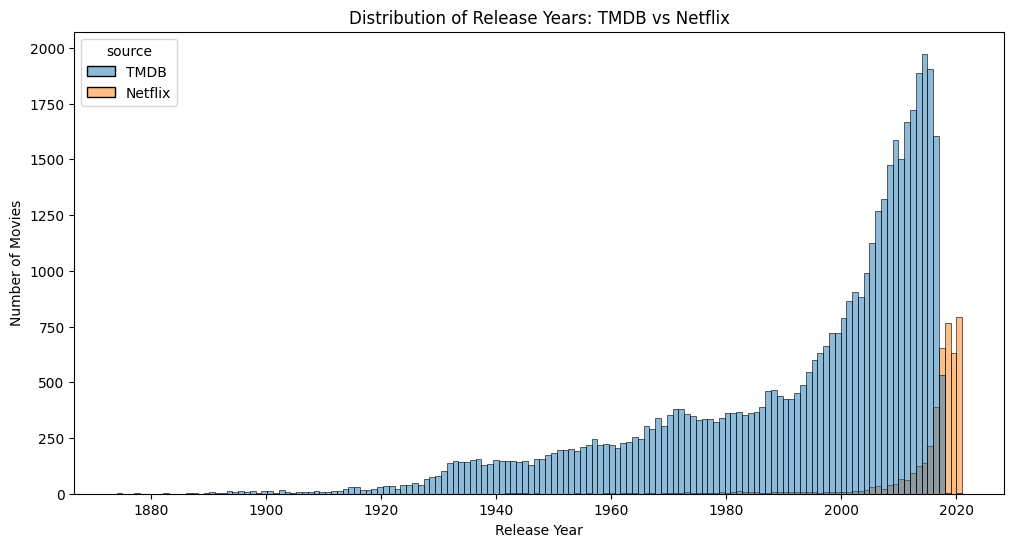

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt


date_df = merged_selected.copy()




year_df = date_df[date_df['release_year'].notna()]

plt.figure(figsize=(12,6))
sns.histplot(
    data=year_df,
    x='release_year',
    hue='source',
    bins=146,
    kde=False
)

plt.title("Distribution of Release Years: TMDB vs Netflix")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

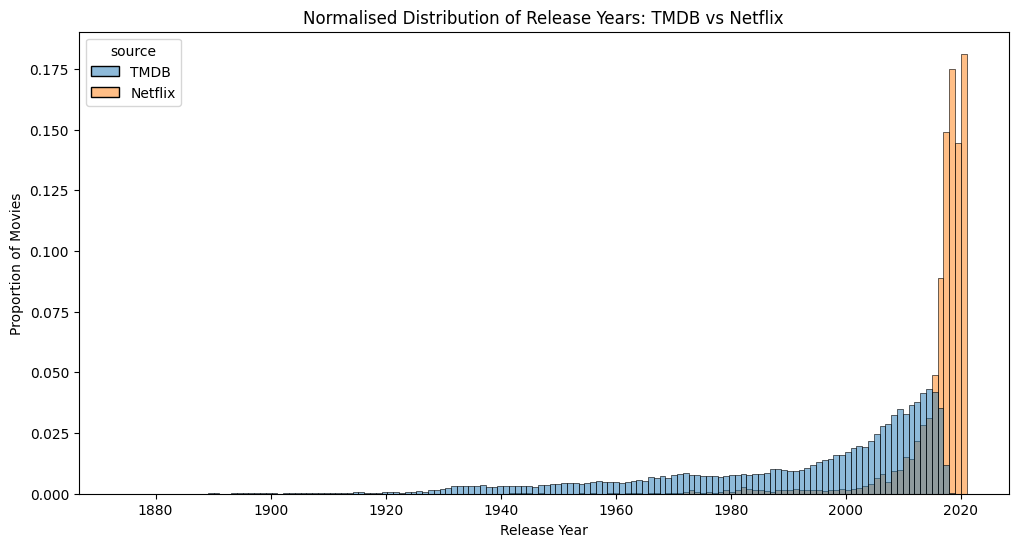

In [55]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=year_df,
    x='release_year',
    hue='source',
    bins=146,
    kde=False,
    stat="density",   
    common_norm=False 
)

plt.title("Normalised Distribution of Release Years: TMDB vs Netflix")
plt.xlabel("Release Year")
plt.ylabel("Proportion of Movies")
plt.show()

Answer to research question: 

The first graph shows that the number of movies on TMDB are much higher than on Netflix. We can use normalisation to show the relative representation and observe the trends rather than absolute numbers. We can use this visualisation to observe the proportion of movies released on Netflix, compared to movies in general, which can help us answer the research question

The distribution of release years shows that both TMDB and Netflix contain more films from recent decades, but Netflix’s catalogue is significantly more concentrated in newer releases. The normalised distribution highlights that Netflix has a notably higher proportion of films released after the mid-2010s compared to the broader population of films in TMDB, suggesting that Netflix strongly prioritises more recent content.

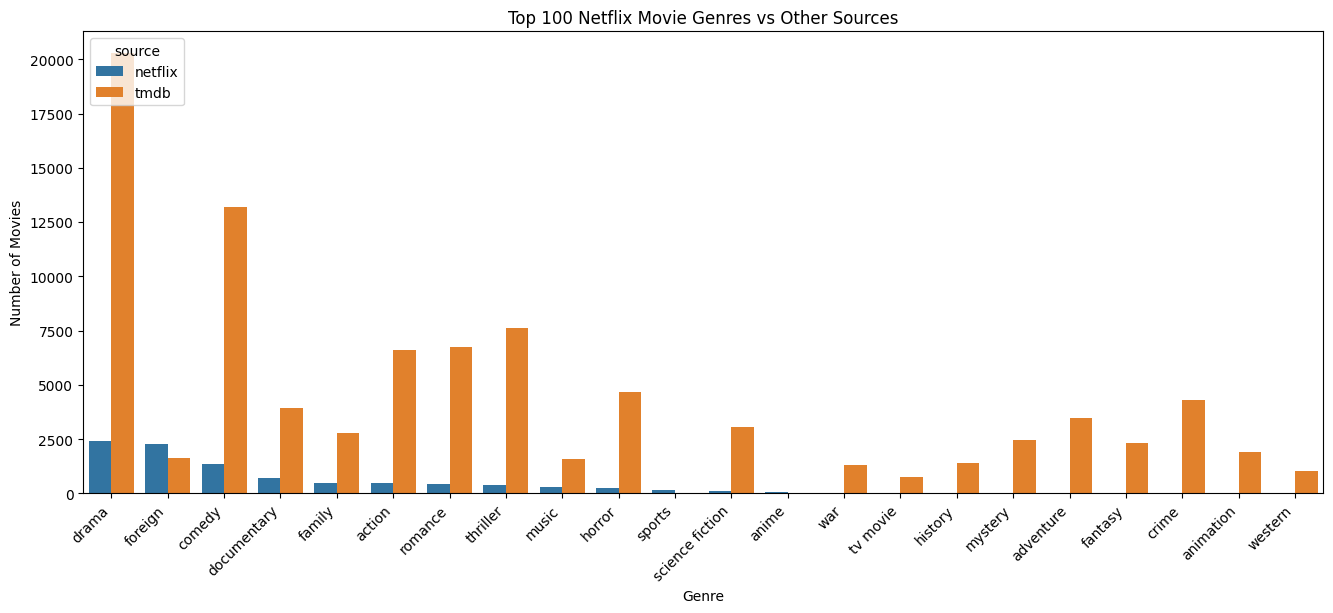

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

genre_df = merged_selected.copy()

genre_df = genre_df.explode('genres')

genre_df = genre_df[genre_df['genres'].notna()]
genre_df['genres'] = genre_df['genres'].str.strip().str.lower()

genre_mapping = {
    'dramas': 'drama',
    'comedies': 'comedy',
    'thrillers': 'thriller',
    'documentaries': 'documentary',
    'children & family movies': 'family',
    'romantic movies': 'romance',
    'horror movies': 'horror',
    'sci-fi & fantasy': 'science fiction',
    'action & adventure': 'action',
    'music & musicals': 'music',
    'anime features': 'anime',
    'sports movies': 'sports',
    'classic movies': 'drama',
    'independent movies': 'drama',
    'international movies': 'foreign',
    'faith & spirituality': 'drama',
    'lgbtq movies': 'drama',
    'stand-up comedy': 'comedy',
    'cult movies': 'drama',
}

allowed_genres = [
    'animation', 'comedy', 'family', 'adventure', 'fantasy', 'romance',
    'drama', 'action', 'crime', 'thriller', 'horror', 'history',
    'science fiction', 'mystery', 'war', 'foreign', 'music',
    'documentary', 'western', 'tv movie', 'sports', 'anime'
]

genre_df['genres'] = genre_df['genres'].replace(genre_mapping)
genre_df = genre_df[genre_df['genres'].isin(allowed_genres)]

genre_df['source'] = genre_df['source'].str.strip().str.lower()

genre_counts = genre_df.groupby(['genres', 'source']).size().reset_index(name='count')

pivot_counts = genre_counts.pivot(index='genres', columns='source', values='count').fillna(0)

top_n = 100
top_genres_ordered = pivot_counts.sort_values(by='netflix', ascending=False).head(top_n).index.tolist()


genre_counts_top = genre_counts[genre_counts['genres'].isin(top_genres_ordered)]


order = pivot_counts.loc[top_genres_ordered].sort_values(by='netflix', ascending=False).index.tolist()


plt.figure(figsize=(16,6))
sns.barplot(
    data=genre_counts_top,
    x='genres',
    y='count',
    hue='source',
    order=order
)
plt.title(f"Top {top_n} Netflix Movie Genres vs Other Sources")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha='right')
plt.show()


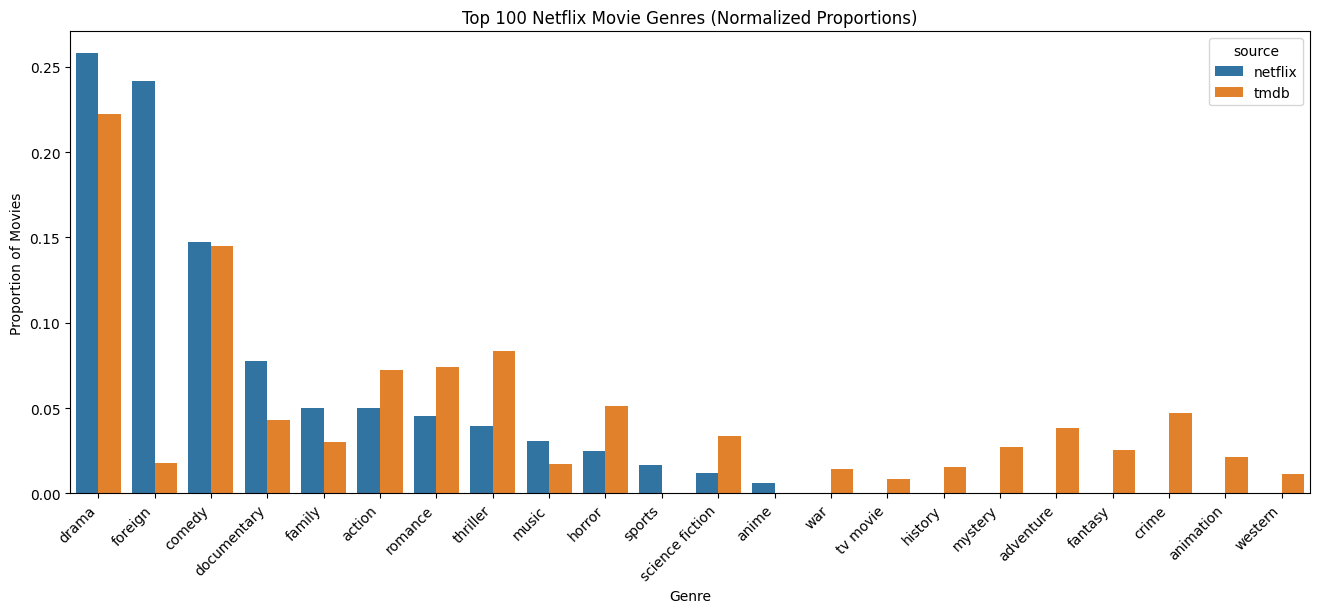

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


genre_df = merged_selected.copy()
genre_df = genre_df.explode('genres')
genre_df = genre_df[genre_df['genres'].notna()]
genre_df['genres'] = genre_df['genres'].str.strip().str.lower()


genre_mapping = {
    'dramas': 'drama',
    'comedies': 'comedy',
    'thrillers': 'thriller',
    'documentaries': 'documentary',
    'children & family movies': 'family',
    'romantic movies': 'romance',
    'horror movies': 'horror',
    'sci-fi & fantasy': 'science fiction',
    'action & adventure': 'action',
    'music & musicals': 'music',
    'anime features': 'anime',
    'sports movies': 'sports',
    'classic movies': 'drama',
    'independent movies': 'drama',
    'international movies': 'foreign',
    'faith & spirituality': 'drama',
    'lgbtq movies': 'drama',
    'stand-up comedy': 'comedy',
    'cult movies': 'drama',
}

allowed_genres = [
    'animation', 'comedy', 'family', 'adventure', 'fantasy', 'romance',
    'drama', 'action', 'crime', 'thriller', 'horror', 'history',
    'science fiction', 'mystery', 'war', 'foreign', 'music',
    'documentary', 'western', 'tv movie', 'sports', 'anime'
]

genre_df['genres'] = genre_df['genres'].replace(genre_mapping)
genre_df = genre_df[genre_df['genres'].isin(allowed_genres)]
genre_df['source'] = genre_df['source'].str.strip().str.lower()


genre_counts = genre_df.groupby(['genres', 'source']).size().reset_index(name='count')


pivot_counts = genre_counts.pivot(index='genres', columns='source', values='count').fillna(0)


pivot_norm = pivot_counts.div(pivot_counts.sum(axis=0), axis=1)



top_n = 100
top_genres_ordered = pivot_counts.sort_values(by='netflix', ascending=False).head(top_n).index.tolist()
pivot_norm_top = pivot_norm.loc[top_genres_ordered].reset_index()


plot_df = pivot_norm_top.melt(id_vars='genres', var_name='source', value_name='proportion')


plt.figure(figsize=(16,6))
sns.barplot(
    data=plot_df,
    x='genres',
    y='proportion',
    hue='source',
    order=top_genres_ordered
)
plt.title(f"Top {top_n} Netflix Movie Genres (Normalized Proportions)")
plt.xlabel("Genre")
plt.ylabel("Proportion of Movies")
plt.xticks(rotation=45, ha='right')
plt.show()


*Answer to research question:

The first graph shows that the number of movies on TMDB are much higher than on Netflix. We can use normalisation to show the relative representation and observe the trends rather than absolute numbers, which will allow us to see how the proportion of genres in Netflix compares to movies in general, and help us answer the research question

After cleaning and standardising the genre data, we see that both datasets are dominated by drama films, but the share of dramas is even higher on Netflix. Netflix also contains a greater proportion of foreign films compared to TMDB. Meanwhile, TMDB shows a wider overall variety of genres, which may reflect either broader coverage or differences in how genre information is recorded. Overall, Netflix’s catalogue appears more concentrated in specific genres and newer releases.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:

If I had more time, I would investigate the large number of missing or zero financial values in the budget and revenue fields, and try to find datasets that compliment this. I would also refine the genre classification process, as some genres present in TMDB appear to be missing in the Netflix subset, possibly due to noise or inconsistencies in the original genre labels. For example, animation is missing in Netflix which is highly unlikely to be the case, would need further investigation. Finally, I would explore additional factors that may explain the differences between Netflix and the broader movie landscape, such as ratings, popularity metrics, or regional availability.